In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#plotting
plt.style.use('seaborn-v0_8-darkgrid')
print("libraries imported successfully.")

All libraries imported successfully.


In [ ]:
#define the ETF tickers
nifty_50_ticker = 'NIFTYBEES.NS'
nifty_next_50_ticker = 'JUNIORBEES.NS'
#dates range
start_date = '2015-11-01'
end_date = '2025-11-01'

#download nifty 50
print(f"downloading {nifty_50_ticker}...")
try:
    nifty_50_data = yf.download(nifty_50_ticker,
                                start=start_date,
                                end=end_date)

    if nifty_50_data.empty:
        print(f"ERROR: No data returned for {nifty_50_ticker}.")
    else:
        print(f"Successfully downloaded {nifty_50_ticker}. Data structure:")
        print(nifty_50_data.head()) #debug

except Exception as e:
    print(f"ERROR while downloading {nifty_50_ticker}: {e}")

#download nifty 50 next
print(f"\ndownloading {nifty_next_50_ticker}...")
try:
    nifty_next_50_data = yf.download(nifty_next_50_ticker,
                                     start=start_date,
                                     end=end_date)

    if nifty_next_50_data.empty:
        print(f"ERROR: No data returned for {nifty_next_50_ticker}.")
    else:
        print(f"Successfully downloaded {nifty_next_50_ticker}. Data structure:")
        print(nifty_next_50_data.head()) #debug

except Exception as e:
    print(f"ERROR downloading {nifty_next_50_ticker}: {e}")

#combine the 'Close' column in both using pd.concat
try:
    #get the 'Close' column from each df
    close_50 = nifty_50_data['Close']
    close_next_50 = nifty_next_50_data['Close']

    #concatenate into a new df
    data = pd.concat([close_50, close_next_50], axis=1, sort=True)

    #set column names
    data.columns = ['NIFTY_50_ETF', 'NIFTY_NEXT_50_ETF']

    #drop any rows with missing values
    data.dropna(inplace=True)

    #checking first 5 rows
    print("\nData combined successfully:")
    print(data.head())

except Exception as e:
    print(f"\nERROR combining data: {e}")
    print("One or both tickers may have failed to download or are empty.")

/tmp/ipython-input-901924023.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty_50_data = yf.download(nifty_50_ticker,
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-901924023.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty_next_50_data = yf.download(nifty_next_50_ticker,
[*********************100%***********************]  1 of 1 completed

Attempting to download NIFTYBEES.NS...
Successfully downloaded NIFTYBEES.NS. Data structure:
Price             Close         High          Low         Open       Volume
Ticker     NIFTYBEES.NS NIFTYBEES.NS NIFTYBEES.NS NIFTYBEES.NS NIFTYBEES.NS
Date                                                                       
2015-11-02    81.653000    81.900002    81.099998    81.861000       349040
2015-11-03    81.808998    82.299004    81.500000    81.970001       251690
2015-11-04    81.574997    82.290001    81.400002    82.099998       505820
2015-11-05    80.787003    81.529999    80.669998    81.476997       358290
2015-11-06    80.544998    81.182999    80.317001    81.000000       615100

Attempting to download JUNIORBEES.NS...
Successfully downloaded JUNIORBEES.NS. Data structure:
Price              Close          High           Low          Open  \
Ticker     JUNIORBEES.NS JUNIORBEES.NS JUNIORBEES.NS JUNIORBEES.NS   
Date                                                           

In [ ]:
#checking last 5 rows
print(data.tail())

            NIFTY_50_ETF  NIFTY_NEXT_50_ETF
Date                                       
2025-10-27    293.350006         748.729980
2025-10-28    293.100006         745.049988
2025-10-29    294.500000         753.640015
2025-10-30    292.579987         751.890015
2025-10-31    291.079987         750.950012


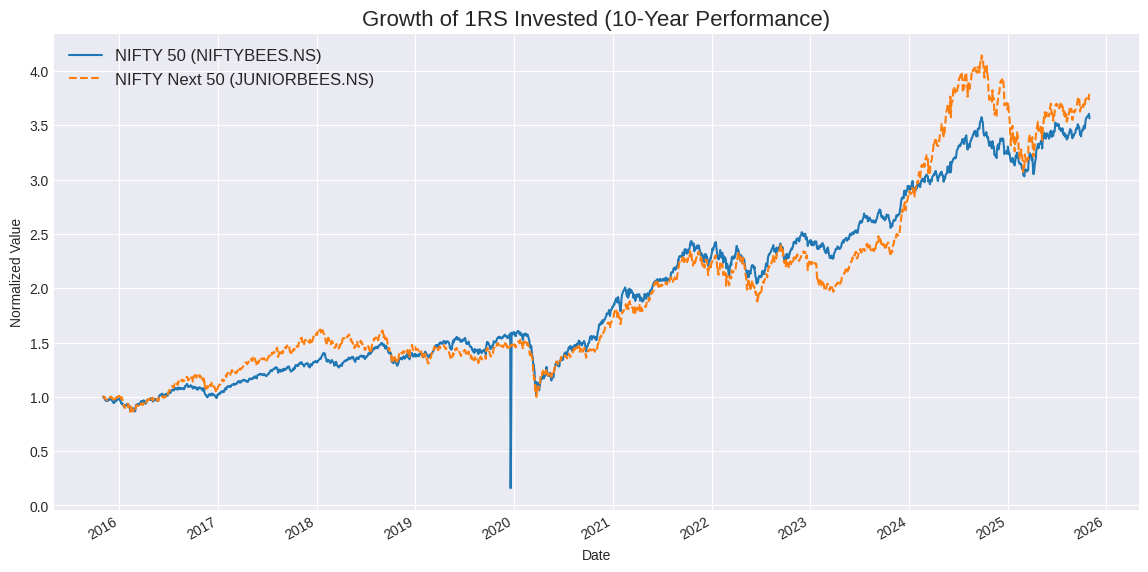

In [ ]:

# data check
if not data.empty:
    #normalize the data and start at 1
    normalized_data = data / data.iloc[0]

    #plotting
    plt.figure(figsize=(14, 7))
    normalized_data['NIFTY_50_ETF'].plot(label='NIFTY 50 (NIFTYBEES.NS)')
    normalized_data['NIFTY_NEXT_50_ETF'].plot(label='NIFTY Next 50 (JUNIORBEES.NS)', linestyle='--')

    plt.title('Growth of 1RS Invested (10-Year Performance)', fontsize=16)
    plt.ylabel('Normalized Value')
    plt.xlabel('Date')
    plt.legend(fontsize=12)
    plt.show()
else:
    print("\nCannot plot chart because data is empty.")

In [ ]:
# calculate CAGR
if 'data' in locals() and not data.empty:

    #function to calculate CAGR
    def calculate_cagr(series):
        """Calculates the Compound Annual Growth Rate for a pandas Series."""
        start_value = series.iloc[0]
        end_value = series.iloc[-1]

        #number of years
        num_days = (series.index[-1] - series.index[0]).days
        num_years = num_days / 365.25  # Use 365.25 to account for leap years

        #CAGR
        cagr = (end_value / start_value) ** (1 / num_years) - 1

        return cagr

    #CAGR for both ETFs
    cagr_nifty_50 = calculate_cagr(data['NIFTY_50_ETF'])
    cagr_nifty_next_50 = calculate_cagr(data['NIFTY_NEXT_50_ETF'])

    #results
    print("10-Year Performance (Raw Returns)")
    print(f"NIFTY 50 ETF (NIFTYBEES) CAGR:     {cagr_nifty_50:.2%}")
    print(f"NIFTY Next 50 ETF (JUNIORBEES) CAGR: {cagr_nifty_next_50:.2%}")

    #calculate difference
    performance_diff = cagr_nifty_next_50 - cagr_nifty_50
    print(f"\nOutperformance of NIFTY Next 50: {performance_diff:.2%}")

else:
    print("The 'data' DataFrame is empty. Please run the previous blocks first.")

10-Year Performance (Raw Returns)
NIFTY 50 ETF (NIFTYBEES) CAGR:     13.56%
NIFTY Next 50 ETF (JUNIORBEES) CAGR: 14.19%

Outperformance of NIFTY Next 50: 0.63%


In [ ]:
#calculate daily returns
daily_returns = data.pct_change().dropna()

#find the worst day for both ETFs
worst_day_nifty_50 = daily_returns['NIFTY_50_ETF'].min()
worst_day_nifty_next_50 = daily_returns['NIFTY_NEXT_50_ETF'].min()

print("--- Data Quality Check (Worst Single Day) ---")
print(f"NIFTY 50 ETF worst day:     {worst_day_nifty_50:.2%}")
print(f"NIFTY Next 50 ETF worst day: {worst_day_nifty_next_50:.2%}")

--- Data Quality Check (Worst Single Day) ---
NIFTY 50 ETF worst day:     -89.93%
NIFTY Next 50 ETF worst day: -9.26%


In [ ]:
#remove outliers

#daily returns
daily_returns = data.pct_change().dropna()

#find date of the worst day for NIFTY 50
outlier_date = daily_returns['NIFTY_50_ETF'].idxmin()
outlier_value = daily_returns['NIFTY_50_ETF'].min()

print(f"--- Outlier Identification ---")
print(f"The outlier was found on: {outlier_date.date()}")
print(f"The erroneous return value on that day was: {outlier_value:.2%}")

#Create the cleaned df by removing outlier
cleaned_daily_returns = daily_returns.drop(outlier_date)

print(f"\nSuccessfully removed the outlier on {outlier_date.date()}.")
print(f"The *new* worst day for NIFTY 50 is: {cleaned_daily_returns['NIFTY_50_ETF'].min():.2%}")

--- Outlier Identification ---
The outlier was found on: 2019-12-19
The erroneous return value on that day was: -89.93%

Successfully removed the outlier on 2019-12-19.
The *new* worst day for NIFTY 50 is: -10.16%


In [ ]:
#show the 5 worst (smallest) values in nifty 50
worst_days_nifty_50 = daily_returns['NIFTY_50_ETF'].sort_values().head(5)

print("--- Top 5 Worst Single Days (NIFTY 50 ETF) ---")
print(worst_days_nifty_50)

--- Top 5 Worst Single Days (NIFTY 50 ETF) ---
Date
2019-12-19   -0.899268
2020-03-23   -0.101646
2020-03-12   -0.074746
2020-03-19   -0.068797
2020-05-04   -0.051641
Name: NIFTY_50_ETF, dtype: float64


In [ ]:
#show the 5 best (largest) values
best_days_nifty_50 = daily_returns['NIFTY_50_ETF'].sort_values(ascending=False).head(5)

print("--- Top 5 Best Single Days (NIFTY 50 ETF) ---")
print(best_days_nifty_50)

--- Top 5 Best Single Days (NIFTY 50 ETF) ---
Date
2019-12-23    8.968543
2020-04-07    0.067213
2019-09-20    0.053092
2020-03-25    0.052471
2021-02-01    0.043942
Name: NIFTY_50_ETF, dtype: float64


In [ ]:
#data cleaning
#find the negative outlier
if 'data' in locals() and not data.empty:
    outlier_date_min = daily_returns['NIFTY_50_ETF'].idxmin()
    val_min = daily_returns['NIFTY_50_ETF'].min()
    #find positive outlier (best day)
    outlier_date_max = daily_returns['NIFTY_50_ETF'].idxmax()
    val_max = daily_returns['NIFTY_50_ETF'].max()

    print("data cleaning")
    print(f"Removing worst outlier on {outlier_date_min.date()} (Value: {val_min:.2%})")
    print(f"Removing best outlier on {outlier_date_max.date()} (Value: {val_max:.2%})")

    #create final df by removing both outlier dates
    cleaned_daily_returns = daily_returns.drop([outlier_date_min, outlier_date_max])

    print("\nSuccessfully removed both outliers.")
    print(f"New worst day for NIFTY 50: {cleaned_daily_returns['NIFTY_50_ETF'].min():.2%}")
    print(f"New best day for NIFTY 50:  {cleaned_daily_returns['NIFTY_50_ETF'].max():.2%}")

    #calculate annual volatility from final cleaned data for nifty 50
    annual_volatility_50 = cleaned_daily_returns['NIFTY_50_ETF'].std() * np.sqrt(252)

    #calculate annual volatility from final cleaned data for nifty next 50
    annual_volatility_next_50 = daily_returns['NIFTY_NEXT_50_ETF'].std() * np.sqrt(252)

    #calculate annual Sharpe Ratio
    RFR = 0.05 #assuming 5% risk-free rate

    #original CAGR values
    sharpe_ratio_50 = (cagr_nifty_50 - RFR) / annual_volatility_50
    sharpe_ratio_next_50 = (cagr_nifty_next_50 - RFR) / annual_volatility_next_50

    #print
    print("\n--- 10-Year FINAL CORRECTED Risk & Risk-Adjusted Return ---")

    print("\nAnnualized Volatility (Risk):")
    print(f"NIFTY 50 ETF (NIFTYBEES):     {annual_volatility_50:.2%}")
    print(f"NIFTY Next 50 ETF (JUNIORBEES): {annual_volatility_next_50:.2%}")

    print("\nAnnualized Sharpe Ratio (Return per Unit of Risk):")
    print(f"NIFTY 50 ETF (NIFTYBEES):     {sharpe_ratio_50:.2f}")
    print(f"NIFTY Next 50 ETF (JUNIORBEES): {sharpe_ratio_next_50:.2f}")

    #final conc
    if sharpe_ratio_next_50 > sharpe_ratio_50:
        print("\nConclusion: The NIFTY Next 50 ETF provided a *superior* risk-adjusted return.")
    else:
        print("\nConclusion: The NIFTY Next 50 ETF provided an *inferior* risk-adjusted return.")

else:
    print("The 'data' DataFrame is empty. Please run the previous blocks first.")

data cleaning
Removing worst outlier on 2019-12-19 (Value: -89.93%)
Removing best outlier on 2019-12-23 (Value: 896.85%)

Successfully removed both outliers.
New worst day for NIFTY 50: -10.16%
New best day for NIFTY 50:  6.72%

--- 10-Year FINAL CORRECTED Risk & Risk-Adjusted Return ---

Annualized Volatility (Risk):
NIFTY 50 ETF (NIFTYBEES):     14.71%
NIFTY Next 50 ETF (JUNIORBEES): 17.03%

Annualized Sharpe Ratio (Return per Unit of Risk):
NIFTY 50 ETF (NIFTYBEES):     0.58
NIFTY Next 50 ETF (JUNIORBEES): 0.54

Conclusion: The NIFTY Next 50 ETF provided an *inferior* risk-adjusted return.


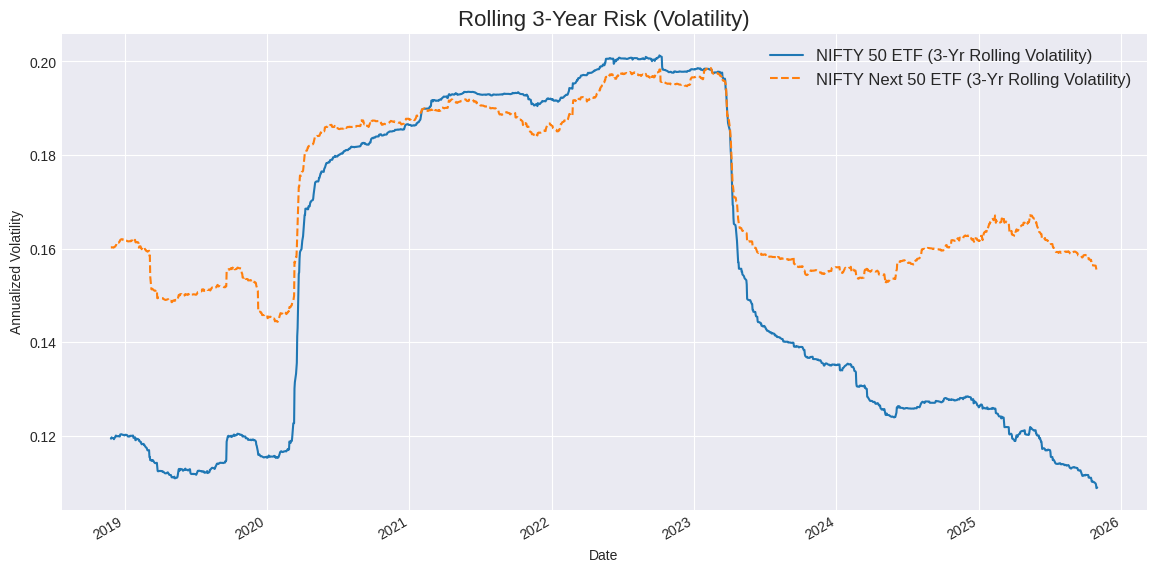

In [ ]:
#check if the 'cleaned_daily_returns'(final) df is present
if 'cleaned_daily_returns' in locals() and not cleaned_daily_returns.empty:

    #rolling window (3 years = 252 of official trading days * 3)
    window = 252 * 3

    #calculate rolling volatility for final NIFTY 50 data
    rolling_vol_50 = cleaned_daily_returns['NIFTY_50_ETF'].rolling(window=window).std() * np.sqrt(252)

    #calculate rolling volatility for final NIFTY Next 50 data
    rolling_vol_next_50 = daily_returns['NIFTY_NEXT_50_ETF'].rolling(window=window).std() * np.sqrt(252)

    #plotting volatility
    plt.figure(figsize=(14, 7))
    rolling_vol_50.plot(label='NIFTY 50 ETF (3-Yr Rolling Volatility)')
    rolling_vol_next_50.plot(label='NIFTY Next 50 ETF (3-Yr Rolling Volatility)', linestyle='--')

    plt.title('Rolling 3-Year Risk (Volatility)', fontsize=16)
    plt.ylabel('Annualized Volatility')
    plt.xlabel('Date')
    plt.legend(fontsize=12)
    plt.show()

else:
    print("The 'cleaned_daily_returns' DataFrame is not available")